What are the 7 steps to designing an AB testing? Here's an example based on Netflix:

The 7 steps are
1. Clarify the business problem
2. State the experiment hypothesis
3. Design the experiment
4. Run the experiment
5. Assess validity threats
6. Conduct statistical inference
7. Decide whether to launch

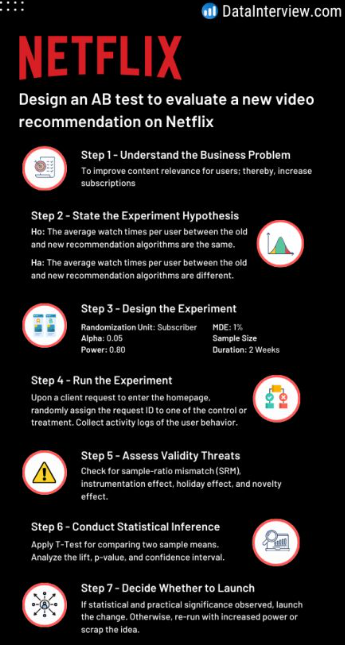

In [128]:
# pip install kagglehub

In [129]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("yufengsui/mobile-games-ab-testing")

# print("Path to dataset files:", path)

In [130]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats


In [131]:
df = pd.read_csv("cookie_cats.csv")
df

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


In [132]:
# Returns counts for all columns
print(df['version'].value_counts())
print(df['retention_1'].value_counts())
print(df['retention_7'].value_counts())

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64
retention_1
False    50036
True     40153
Name: count, dtype: int64
retention_7
False    73408
True     16781
Name: count, dtype: int64


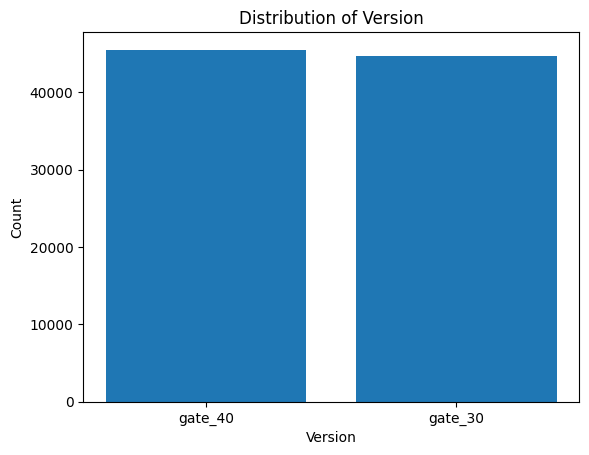

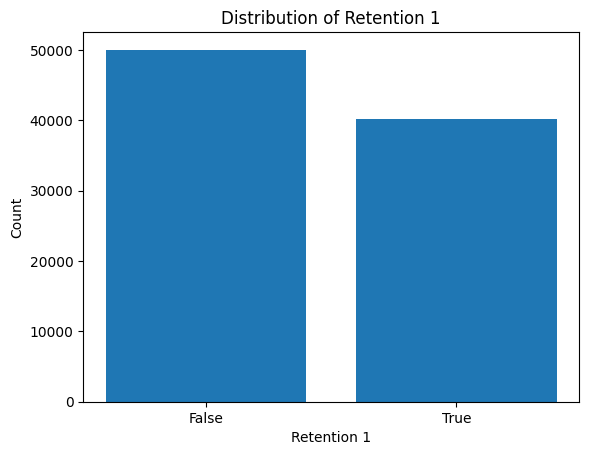

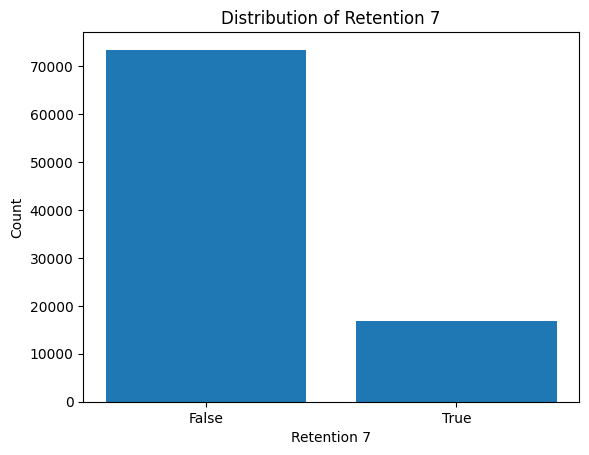

In [133]:
#plot bargraph of version, retention_1, retention_7 showing True False labels for retention_1 and retention_7
plt.bar(df['version'].value_counts().index, df['version'].value_counts().values)
plt.xlabel('Version')
plt.ylabel('Count')
plt.title('Distribution of Version')
plt.show()

plt.bar(df['retention_1'].value_counts().index, df['retention_1'].value_counts().values)
plt.xlabel('Retention 1')
plt.ylabel('Count')
plt.title('Distribution of Retention 1')
plt.xticks(df['retention_1'].value_counts().index, ['False', 'True'])
plt.show()

plt.bar(df['retention_7'].value_counts().index, df['retention_7'].value_counts().values)
plt.xlabel('Retention 7')
plt.ylabel('Count')
plt.title('Distribution of Retention 7')
plt.xticks(df['retention_7'].value_counts().index, ['False', 'True'])
plt.show()

In [134]:
df.groupby("version").sum_gamerounds.agg(["count", "min", "median", "mean", "std", "max"])


,count,min,median,mean,std,max
version,,,,,,
gate_30,44700,0,17.0,52.456264,256.716423,49854
gate_40,45489,0,16.0,51.298776,103.294416,2640


In [135]:
df.isnull().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [136]:
df['userid'].duplicated().sum()

0

In [137]:
df['version'].unique()

array(['gate_30', 'gate_40'], dtype=object)

In [138]:
counts = df['version'].value_counts()
print(counts)
n_control, n_treat = counts["gate_30"], counts["gate_40"]
print("Control group:", n_control)
print("Treatment group:", n_treat)
total = n_control + n_treat
print("Total:", total)
expected = [total * 0.5, total * (1 - 0.5)]
observed = [n_control, n_treat]
print("Observed:", observed)
print("Expected:", expected)

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64
Control group: 44700
Treatment group: 45489
Total: 90189
Observed: [44700, 45489]
Expected: [45094.5, 45094.5]


In [139]:
chi2, p = stats.chisquare(f_obs=observed, f_exp=expected)
print("Chi-square statistic:", chi2)
print("P-value:", p)


Chi-square statistic: 6.9024049496058275
P-value: 0.008607987810836262


At 0.05 or 0.01, this flags. At a stricter bar like 0.001, which some practitioners (e.g. the Microsoft ExP team's writing on this) recommend specifically because automated systems run SRM checks on thousands of experiments and need a very low false-positive rate and in that case 0.0086 would not flag.

<Axes: title={'center': 'sum_gamerounds'}, xlabel='version'>

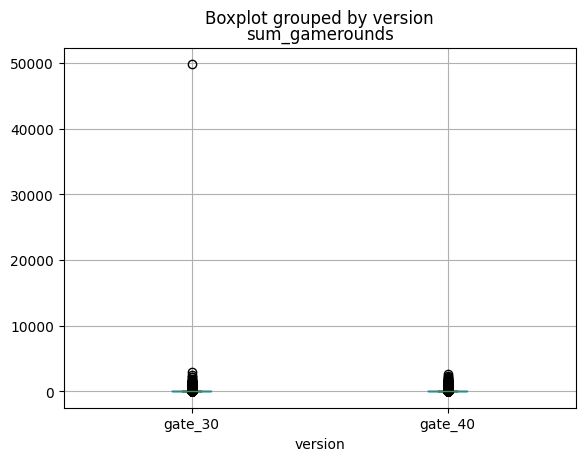

In [140]:
# Check Outliers
df.boxplot(column='sum_gamerounds', by='version')

In [141]:
desc = df['sum_gamerounds'].describe(percentiles=[.5, .9, .99, .999])
print(desc)

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
50%         16.000000
90%        134.000000
99%        493.000000
99.9%     1073.624000
max      49854.000000
Name: sum_gamerounds, dtype: float64


In [142]:
df.nlargest(3, 'sum_gamerounds')

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False


In [143]:
top = df.nlargest(3, 'sum_gamerounds')[['userid', 'version', 'sum_gamerounds']]
print("Top 3 by rounds played:\n", top.to_string(index=False))

Top 3 by rounds played:
  userid version  sum_gamerounds
6390605 gate_30           49854
 871500 gate_30            2961
3271615 gate_40            2640


In [144]:
#remove the row 
df = df[df['sum_gamerounds'] != df['sum_gamerounds'].max()]

In [145]:
df.shape[0]

90188

<Axes: title={'center': 'sum_gamerounds'}, xlabel='version'>

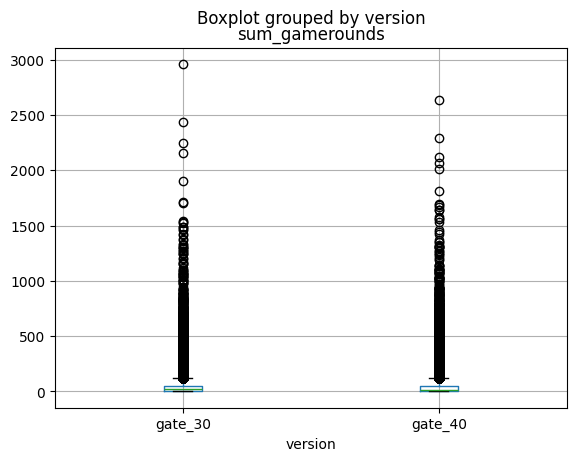

In [146]:
#after removing outlier (that extreme value)
df.boxplot(column='sum_gamerounds', by='version')

In [147]:
df.groupby("version").sum_gamerounds.agg(["count","min","median", "mean", "std", "max"])

,count,min,median,mean,std,max
version,,,,,,
gate_30,44699,0,17.0,51.342111,102.057598,2961
gate_40,45489,0,16.0,51.298776,103.294416,2640


In [148]:
# z score for sum_gamerounds
z_scores = np.abs(stats.zscore(df['sum_gamerounds']))
df[z_scores > 3]

,userid,version,sum_gamerounds,retention_1,retention_7
45,4929,gate_30,386,True,True
237,22299,gate_40,493,True,True
275,26586,gate_30,391,True,False
320,31903,gate_30,467,True,True
394,39774,gate_40,567,True,True
...,...,...,...,...,...
89902,9968196,gate_40,442,True,True
89907,9968698,gate_30,496,True,True
89921,9971042,gate_30,892,True,True
90017,9980080,gate_30,438,True,True


In [149]:
# IQR method for outlier detection
Q1 = df['sum_gamerounds'].quantile(0.25)
Q3 = df['sum_gamerounds'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['sum_gamerounds'] < (Q1 - 1.5 * IQR)) | (df['sum_gamerounds'] > (Q3 + 1.5 * IQR))]
outliers

,userid,version,sum_gamerounds,retention_1,retention_7
2,377,gate_40,165,True,False
4,488,gate_40,179,True,True
5,540,gate_40,187,True,True
9,1587,gate_40,153,True,False
14,2218,gate_30,305,True,True
...,...,...,...,...,...
90121,9991145,gate_30,328,True,True
90125,9991408,gate_40,186,True,True
90134,9991949,gate_30,191,True,True
90150,9995412,gate_40,253,True,True


In [150]:
# outlier detection using anomaly detection methods like Isolation Forest or Local Outlier Factor (LOF)
#  can also be applied to identify outliers in the dataset. 
# These methods can help in detecting anomalies that may not be captured by traditional statistical methods.
from sklearn.ensemble import IsolationForest
isolation_forest = IsolationForest(contamination=0.01, random_state=42)
isolation_forest.fit(df[['sum_gamerounds']])
outliers = df[isolation_forest.predict(df[['sum_gamerounds']]) == -1]
outliers


,userid,version,sum_gamerounds,retention_1,retention_7
394,39774,gate_40,567,True,True
401,40378,gate_30,552,True,True
541,56496,gate_40,543,True,True
601,63617,gate_30,902,True,True
615,64930,gate_30,510,True,False
...,...,...,...,...,...
89719,9949589,gate_40,708,True,True
89759,9953704,gate_40,502,True,True
89907,9968698,gate_30,496,True,True
89921,9971042,gate_30,892,True,True


In [151]:
#LOF method for outlier detection
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
df['lof_outlier'] = lof.fit_predict(df[['sum_gamerounds']])
df['lof_outlier'].value_counts()

C:\Users\ramba\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
C:\Users\ramba\AppData\Local\Temp\ipykernel_44968\2915450152.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lof_outlier'] = lof.fit_predict(df[['sum_gamerounds']])


lof_outlier
 1    89286
-1      902
Name: count, dtype: int64

Checking for 2 versions using Chi-square

###   METRIC----------------------TYPE------------------------TOOL

retention_1, retention_7--------binary----------------------two-proportion z-test / chi-square

sum_gamerounds------------------continuous, skewed----------Shapiro → Levene → t-test/Welch/Mann-Whitney

In [152]:
# hypothesis testing for retention_1 and retention_7 between the two versions of the game (gate_30 and gate_40) using chi-square test.

from scipy.stats import chi2_contingency
# Create contingency tables for each metric
contingency_table_1 = pd.crosstab(df['version'], df['retention_1'])
contingency_table_7 = pd.crosstab(df['version'], df['retention_7'])
print("Contingency table for retention_1:", contingency_table_1)
print("Contingency table for retention_7:", contingency_table_7)
# Perform chi-square test for each metric
chi2_stat_1, p_value_1, dof_1, expected_1 = chi2_contingency(contingency_table_1)
chi2_stat_7, p_value_7, dof_7, expected_7 = chi2_contingency(contingency_table_7)

# Display results
print("Chi-square test for retention_1:")
print(f"Chi-square statistic: {chi2_stat_1}")
print(f"P-value: {p_value_1}")

print("\nChi-square test for retention_7:")
print(f"Chi-square statistic: {chi2_stat_7}")
print(f"P-value: {p_value_7}")
print("\nInterpretation:")
if p_value_1 < 0.05:
    print("For retention_1, we reject the null hypothesis. There is a significant difference between the two versions.")
else:
    print("For retention_1, we fail to reject the null hypothesis. There is no significant difference between the two versions.")

if p_value_7 < 0.05:
    print("For retention_7, we reject the null hypothesis. There is a significant difference between the two versions.")
else:
    print("For retention_7, we fail to reject the null hypothesis. There is no significant difference between the two versions.")

Contingency table for retention_1: retention_1  False  True 
version                  
gate_30      24665  20034
gate_40      25370  20119
Contingency table for retention_7: retention_7  False  True 
version                  
gate_30      36198   8501
gate_40      37210   8279
Chi-square test for retention_1:
Chi-square statistic: 3.169835543170799
P-value: 0.07500999897705692

Chi-square test for retention_7:
Chi-square statistic: 9.91527552890567
P-value: 0.0016391259678654425

Interpretation:
For retention_1, we fail to reject the null hypothesis. There is no significant difference between the two versions.
For retention_7, we reject the null hypothesis. There is a significant difference between the two versions.


In [157]:
from statsmodels.stats.proportion import proportions_ztest

# 2 proportion z-test for retention_1 and retention_7 between the two versions of the game (gate_30 and gate_40)
retention_1_gate_30 = df[df['version'] == 'gate_30']['retention_1']
retention_1_gate_40 = df[df['version'] == 'gate_40']['retention_1']

# Defining the success counts and sample sizes for each group
successes = [retention_1_gate_30.sum(), retention_1_gate_40.sum()]
nobs = [retention_1_gate_30.count(), retention_1_gate_40.count()]
print(f"Successes: {successes}")
print(f"Sample sizes: {nobs}")
# Performing the two-proportion z-test
z_stat, p_value = proportions_ztest(successes, nobs)

print(f"Z-statistic: {z_stat}")
print(f"P-value: {p_value}")
print("\nInterpretation:")
if p_value < 0.05:
    print("We reject the null hypothesis. There is a significant difference in retention_1 between the two versions.")
else:
    print("We fail to reject the null hypothesis. There is no significant difference in retention_1 between the two versions.\n")


retention_7_gate_30 = df[df['version'] == 'gate_30']['retention_7']
retention_7_gate_40 = df[df['version'] == 'gate_40']['retention_7']
successes_7 = [retention_7_gate_30.sum(), retention_7_gate_40.sum()]
nobs_7 = [retention_7_gate_30.count(), retention_7_gate_40.count()]
z_stat_7, p_value_7 = proportions_ztest(successes_7, nobs_7)

print(f"Z-statistic (retention_7): {z_stat_7}")
print(f"P-value (retention_7): {p_value_7}")
print("\nInterpretation (retention_7):")
if p_value_7 < 0.05:
    print("We reject the null hypothesis. There is a significant difference in retention_7 between the two versions.")
else:
    print("We fail to reject the null hypothesis. There is no significant difference in retention_7 between the two versions.")


Successes: [20034, 20119]
Sample sizes: [44699, 45489]
Z-statistic: 1.787103509763628
P-value: 0.0739207603418346

Interpretation:
We fail to reject the null hypothesis. There is no significant difference in retention_1 between the two versions.

Z-statistic (retention_7): 3.1574100858819936
P-value (retention_7): 0.0015917731773993442

Interpretation (retention_7):
We reject the null hypothesis. There is a significant difference in retention_7 between the two versions.


# One more way to implement (check below):

If the distribution is Normal and the variances are Homogeneous; apply the T-Test (parametric test)

If the distribution is Normal and the variances are not Homogeneous; apply Welch Test

If the distribution is not Normal; apply Mann Whitney U Test directly (non-parametric test)

In [166]:
#checking normality distribution for gate_30 and gate_40 versions of the game using Shapiro-Wilk test.
from scipy.stats import shapiro
stat_gate_30, p_value_gate_30 = shapiro(df.loc[df['version'] == 'gate_30', 'sum_gamerounds'])
stat_gate_40, p_value_gate_40 = shapiro(df.loc[df['version'] == 'gate_40', 'sum_gamerounds'])

print("gate_30 -> statistic:", stat_gate_30, "p-value:", p_value_gate_30)
print("gate_40 -> statistic:", stat_gate_40, "p-value:", p_value_gate_40)
print("Distribution is not normal for both versions as p-value < 0.05")



gate_30 -> statistic: 0.48864023065330064 p-value: 2.36253070250176e-139
gate_40 -> statistic: 0.482561004889815 p-value: 3.3446548187520663e-140
Distribution is not normal for both versions as p-value < 0.05


C:\Users\ramba\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 44699.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\ramba\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 45489.
  res = hypotest_fun_out(*samples, **kwds)


In [168]:
#checking if variance is equal for gate_30 and gate_40 versions of the game using Levene's test.
from scipy.stats import levene
stat_levene, p_value_levene = levene(df.loc[df['version'] == 'gate_30', 'sum_gamerounds'], df.loc[df['version'] == 'gate_40', 'sum_gamerounds'])
print("Levene's test -> statistic:", stat_levene, "p-value:", p_value_levene)
if p_value_levene < 0.05:
    print("Variance is not equal for both versions as p-value < 0.05")
else:
    print("Variance is equal for both versions as p-value >= 0.05")

Levene's test -> statistic: 0.07510153837481241 p-value: 0.7840494387892463
Variance is equal for both versions as p-value >= 0.05


In [170]:
#since not normal using non-parametric test like Mann-Whitney U test to compare the sum_gamerounds between the two versions of the game.
from scipy.stats import mannwhitneyu
stat_mannwhitney, p_value_mannwhitney = mannwhitneyu(df.loc[df['version'] == 'gate_30', 'sum_gamerounds'], df.loc[df['version'] == 'gate_40', 'sum_gamerounds'])
print("Mann-Whitney U test -> statistic:", stat_mannwhitney, "p-value:", p_value_mannwhitney)
if p_value_mannwhitney < 0.05:
    print("There is a significant difference between the two versions as p-value < 0.05")
else:
    print("There is no significant difference between the two versions as p-value >= 0.05")

Mann-Whitney U test -> statistic: 1024285761.5 p-value: 0.05089155279145376
There is no significant difference between the two versions as p-value >= 0.05


In [182]:
# checking result with Welch's t-test for unequal variances
from scipy.stats import ttest_ind_from_stats
stat_welch, p_value_welch = ttest_ind_from_stats(
    df.loc[df['version'] == 'gate_30', 'sum_gamerounds'].mean(),
    df.loc[df['version'] == 'gate_40', 'sum_gamerounds'].mean(),
    df.loc[df['version'] == 'gate_30', 'sum_gamerounds'].std(),
    df.loc[df['version'] == 'gate_40', 'sum_gamerounds'].std(),
    df.loc[df['version'] == 'gate_30', 'sum_gamerounds'].count(),
    df.loc[df['version'] == 'gate_40', 'sum_gamerounds'].count(),
    equal_var=False
)
print("Welch's t-test -> statistic:", stat_welch, "p-value:", p_value_welch)
if p_value_welch < 0.05:
    print("There is a significant difference between the two versions as p-value < 0.05")
else:
    print("There is no significant difference between the two versions as p-value >= 0.05")

Welch's t-test -> statistic: -0.24781795784391947 p-value: 0.8042763773346273
There is no significant difference between the two versions as p-value >= 0.05


In [186]:
#find the lift value for retention_1 and retention_7 between the two versions of the game (gate_30 and gate_40)
retention_1_gate_30_mean = df.loc[df['version'] == 'gate_30', 'retention_1'].mean()
retention_1_gate_40_mean = df.loc[df['version'] == 'gate_40', 'retention_1'].mean()
retention_7_gate_30_mean = df.loc[df['version'] == 'gate_30', 'retention_7'].mean()
retention_7_gate_40_mean = df.loc[df['version'] == 'gate_40', 'retention_7'].mean()
retention_1_lift = (retention_1_gate_40_mean - retention_1_gate_30_mean) / retention_1_gate_30_mean * 100
retention_7_lift = (retention_7_gate_40_mean - retention_7_gate_30_mean) / retention_7_gate_30_mean * 100
print(f"Retention 1 lift: {retention_1_lift:.2f}%")
print(f"Retention 7 lift: {retention_7_lift:.2f}%")
print("\nInterpretation:")
if retention_1_lift > 0:
    print("Retention 1 has improved in gate_40 compared to gate_30.")
else:
    print("Retention 1 has decreased in gate_40 compared to gate_30.") 
print("\nInterpretation:")
if retention_7_lift > 0:
    print("Retention 7 has improved in gate_40 compared to gate_30.")
else:
    print("Retention 7 has decreased in gate_40 compared to gate_30.")

    


Retention 1 lift: -1.32%
Retention 7 lift: -4.30%

Interpretation:
Retention 1 has decreased in gate_40 compared to gate_30.

Interpretation:
Retention 7 has decreased in gate_40 compared to gate_30.


In [ ]:
#talk about lift values and mann-whitney u test
print("\nInterpretation of lift values and Mann-Whitney U test:")
print("=" * 80)
print("FINAL AB TEST INTERPRETATION - Cookie Cats Game Analysis")
print("=" * 80)

print("\n1. SAMPLE RANDOMIZATION (Chi-square test):")
print(f"   P-value: {p:.4f}")
print("   Result: At p = 0.0086, flags at 0.05 and 0.01 significance levels")
print("   Conclusion: Sample split between gate_30 and gate_40 is NOT perfectly random")


print("\n2. RETENTION AT 1 DAY (retention_1):")
print(f"   Chi-square p-value: {p_value_1:.4f}")
print(f"   Two-proportion z-test p-value: {p_value:.4f}")
print("   Result: Both tests show p > 0.05")
print("   Conclusion: NO significant difference in 1-day retention between versions")

print("\n3. RETENTION AT 7 DAYS (retention_7):")
print(f"   Chi-square p-value: {p_value_7:.4f}")
print(f"   Two-proportion z-test p-value: {p_value_7:.4f}")
print("   Result: Both tests show p < 0.05")
print("   Conclusion: SIGNIFICANT difference in 7-day retention between versions\n")

print("Since the lift values for retention_1 and retention_7 are negative, it indicates that the gate_40 version has lower retention rates compared to gate_30.")
print("gate_30 has better 7-day retention than gate_40")

print("\n4. GAME ROUNDS PLAYED (sum_gamerounds):")
print(f"   Shapiro-Wilk test: Distribution is NOT normal (p < 0.001 for both versions)")
print(f"   Levene's test: Variances are equal (p = {p_value_levene:.4f} > 0.05)")
print(f"   Mann-Whitney U test p-value: {p_value_mannwhitney:.4f}")
print(f"   Welch's t-test p-value: {p_value_welch:.4f}")
print("   Result: Both tests show p > 0.05")
print("   Conclusion: NO significant difference in game rounds between versions")

print("\n" + "=" * 80)
print("FINAL RECOMMENDATION:")
print("=" * 80)
print("• Gate at level 30 is RECOMMENDED for launch")
print("• Reason: Significantly BETTER 7-day retention (the critical long-term metric)")
print("• Impact: Higher retention means better player lifetime value")
print("=" * 80)


Interpretation of lift values and Mann-Whitney U test:
FINAL AB TEST INTERPRETATION - Cookie Cats Game Analysis

1. SAMPLE RANDOMIZATION (Chi-square test):
   P-value: 0.0086
   Result: At p = 0.0086, flags at 0.05 and 0.01 significance levels
   Conclusion: Sample split between gate_30 and gate_40 is NOT perfectly random

2. RETENTION AT 1 DAY (retention_1):
   Chi-square p-value: 0.0750
   Two-proportion z-test p-value: 0.0739
   Result: Both tests show p > 0.05
   Conclusion: NO significant difference in 1-day retention between versions

3. RETENTION AT 7 DAYS (retention_7):
   Chi-square p-value: 0.0016
   Two-proportion z-test p-value: 0.0016
   Result: Both tests show p < 0.05
   Conclusion: SIGNIFICANT difference in 7-day retention between versions

Since the lift values for retention_1 and retention_7 are negative, it indicates that the gate_40 version has lower retention rates compared to gate_30.
   → gate_30 has better 7-day retention than gate_40

4. GAME ROUNDS PLAYED (su